In [90]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

sns.set_palette('colorblind')

In [91]:
# COLLECT DAILY ADJUSTED CLOSE DATA (SPY)

ticker = "SPY"

df = yf.download(
    ticker,
    start="1995-01-01",
    end="2026-01-01",
    interval="1d",
    auto_adjust=True,
    progress=True
)

df = df[["Close"]].dropna()
df.columns = ["Close"]

df.head()

[*********************100%***********************]  1 of 1 completed


,Close
Date,
1995-01-03,26.443813
1995-01-04,26.570169
1995-01-05,26.570169
1995-01-06,26.597254
1995-01-09,26.624331


In [92]:
# CALCULATE LOG RETURNS

df["log_return"] = np.log(df["Close"]).diff()
returns = df["log_return"].dropna()

print(returns.describe())
print("NaNs:", returns.isna().sum())

count    7801.000000
mean        0.000416
std         0.012004
min        -0.115887
25%        -0.004556
50%         0.000726
75%         0.006173
max         0.135577
Name: log_return, dtype: float64
NaNs: 0


In [93]:
df.to_csv("30yr_returns.csv")

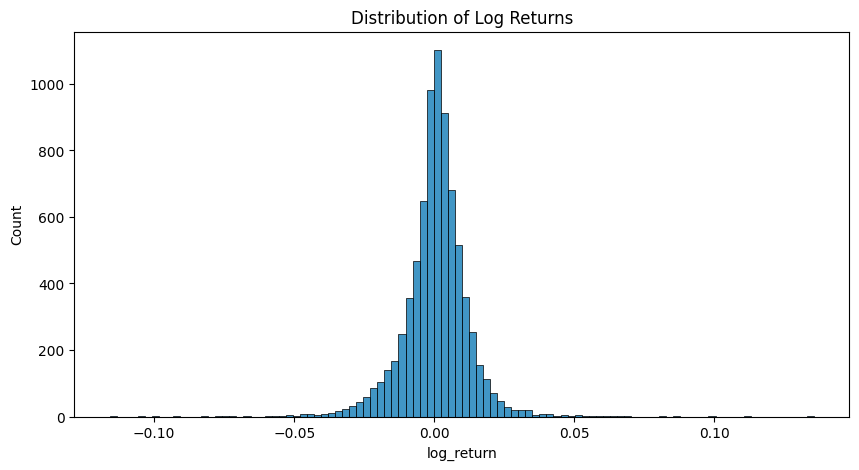

In [94]:
# VISUALIZE DISTRIBUTION OF LOG RETURNS

plt.figure(figsize=(10,5))
sns.histplot(returns, bins=100, kde=False)
plt.title("Distribution of Log Returns")
plt.show()

In [95]:
# DESCRIPTIVE STATISTICS

returns = df['log_return'].dropna()

mean   = returns.mean()
std    = returns.std()
skew   = returns.skew()
kurt   = returns.kurt()

print(f"Mean:             {mean:.6f}")
print(f"Std Dev:          {std:.6f}")
print(f"Skewness:         {skew:.4f}")
print(f"Excess Kurtosis:  {kurt:.4f}")

Mean:             0.000416
Std Dev:          0.012004
Skewness:         -0.2474
Excess Kurtosis:  10.9957


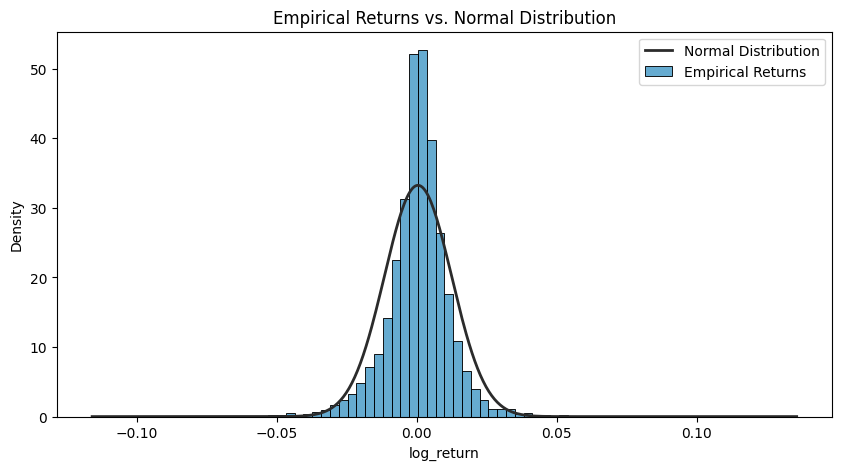

In [96]:
# EMPIRICAL RETURNS VS NORMAL DISTRIBUTION

x = np.linspace(returns.min(), returns.max(), 500)

mu = returns.mean()
sigma = returns.std()

normal_pdf = stats.norm.pdf(x, mu, sigma)

plt.figure(figsize=(10,5))

sns.histplot(
    returns,
    bins=80,
    stat="density",
    alpha=0.6,
    label="Empirical Returns"
)

plt.plot(
    x,
    normal_pdf,
    linewidth=2,
    color="#2b2b2b",
    label="Normal Distribution"
)

plt.legend()
plt.title("Empirical Returns vs. Normal Distribution")
plt.show()

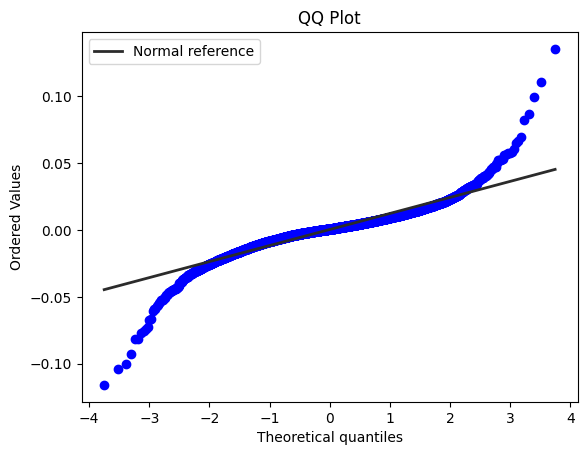

In [97]:
# QQ-Plot

res = stats.probplot(
    returns,
    dist="norm",
    plot=plt,
    fit=False
)

osm = res[0]
plt.plot(
    osm,
    mu + sigma * osm,
    linewidth=2,
    color="#2b2b2b",
    label="Normal reference"
)

plt.legend()
plt.title("QQ Plot")
plt.show()

In [98]:
# JARQUE-BERA NORMALITY TEST

jb_stat, jb_pvalue = stats.jarque_bera(returns)

print(f"Jarque-Bera statistic: {jb_stat:.2f}")
print(f"p-value: {jb_pvalue:.2f}")
print(f"Reject normality at 5% level: {jb_pvalue < 0.05}")

Jarque-Bera statistic: 39323.01
p-value: 0.00
Reject normality at 5% level: True


In [99]:
# SUMMARY OF INSIGHTS

print("SUMMARY")
print(f"- Excess kurtosis: {kurt:.2f} (normal = 0) indicates heavy fat tails.")
print(f"- Skew: {skew:.2f} shows {'left' if skew < 0 else 'right'}-skewed.")
print(f"- Jarque-Bera p-value: {jb_pvalue:.2f}")
print()
if jb_pvalue < 0.05:
    print("CONCLUSION: The null hypothesis of normality is decisively REJECTED (p < 0.05).")
    print("Daily returns exhibit significant excess kurtosis and skew inconsistent with a normal distribution.")

SUMMARY
- Excess kurtosis: 11.00 (normal = 0) indicates heavy fat tails.
- Skew: -0.25 shows left-skewed.
- Jarque-Bera p-value: 0.00

CONCLUSION: The null hypothesis of normality is decisively REJECTED (p < 0.05).
Daily returns exhibit significant excess kurtosis and skew inconsistent with a normal distribution.
